intro...

---
# 1. Setup

In [2]:
# install dependencies
!pip install -qq transformer_lens einops matplotlib

In [4]:
%%capture
import torch
import numpy as np
import einops
import matplotlib.pyplot as plt
import os
import warnings
from transformer_lens import HookedTransformer

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)

In [5]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cpu


In [ ]:
# load GPT-2 Small: ~163M params, 12 layers, 12 heads, d_model=768
# standard sandbox model for mechanistic interpretability research.
model = HookedTransformer.from_pretrained(
    'gpt2',
    center_unembed = True,
    center_writing_weights = True, # these two subtract mean from embedding and unembedding matrices, normalization trick from ELhage et al. (2021), makes residual stream decomposition cleaner, else there will be constant bias term floating through each layer which affects attribution scores
    fold_ln = True, # folds LayerNorm params into surrounding weight matrices so residual stream is truly a linear sum of contributions
    refactor_factored_attn_matrices = True # rewrites attn. weight matrices to make QK and OV more interpretable
).to(DEVICE)
model.eval()

n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads
d_model  = model.cfg.d_model

print(f'Layers: {n_layers}, Heads: {n_heads}, d_model: {d_model}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cpu
Layers: 12, Heads: 12, d_model: 768
Total parameters: 163,049,041


In [14]:
# sanity check
prompt = 'The Eiffel Tower is located in the city of'
logits, cache = model.run_with_cache(prompt)
probs = torch.softmax(logits[0, -1], dim = -1)
top5 = torch.topk(probs, 5)
print('Top 5 predictions:')
for tok, p in zip(top5.indices, top5.values):
    token_str = model.to_single_str_token(tok.item())
    print(f'  {repr(token_str):15s}  {p.item():.4f}')

Top 5 predictions:
  ' London'        0.0691
  ' Paris'         0.0688
  ' Amsterdam'     0.0403
  ' Berlin'        0.0323
  ' New'           0.0279


> Note: GPT-2 Small ranks London marginally above Paris here. This is due to model's limited factual associations at this very small scale, not an error.

---
# 2. Attention Pattern Visualization

Raw attention patterns across heads in layers 0, 5, and 11. This gives intuition
for the diversity of attention behaviors before formally identifying circuits.
Taxonomy of head types (previous token heads, induction heads, etc.) from
Elhage et al. (2021).

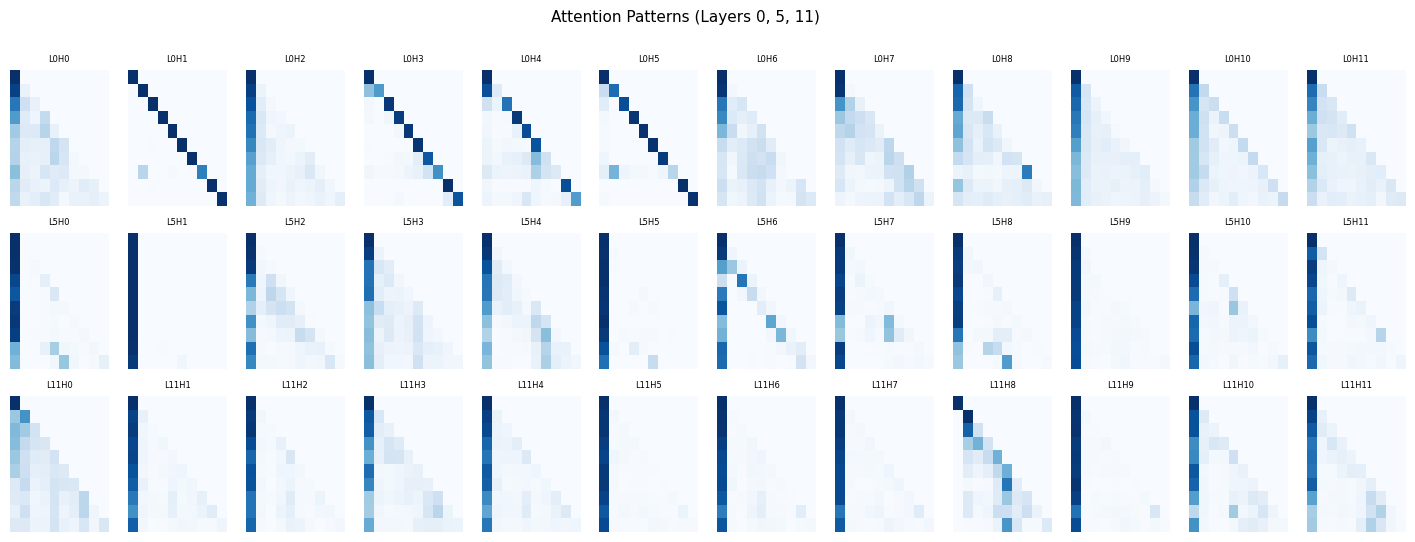

In [ ]:
attn_prompt = 'The quick brown fox jumped over the lazy dog'
_, attn_cache = model.run_with_cache(attn_prompt)

target_layers = [0, 5, 11]
fig, axes = plt.subplots(len(target_layers), n_heads, figsize = (n_heads * 1.5, len(target_layers) * 2))
fig.suptitle('Attention Patterns (Layers 0, 5, 11)', fontsize = 11)

for row, layer in enumerate(target_layers):
    # pattern shape: [batch, n_heads, dest_pos, src_pos]
    patterns = attn_cache['pattern', layer][0].cpu().numpy()
    for head in range(n_heads):
        ax = axes[row, head]
        ax.imshow(patterns[head], cmap = 'Blues', vmin = 0, vmax = 1, aspect = 'auto')
        ax.set_title(f'L{layer}H{head}', fontsize = 6)
        ax.axis('off')

plt.savefig('figures/attention_patterns.png', dpi = 120, bbox_inches = 'tight')
plt.show()

---
# 3. Induction Head Detection

intro...

In [21]:
BATCH   = 20
SEQ_LEN = 50

rand_tokens = torch.randint(1000, model.cfg.d_vocab - 1, (BATCH, SEQ_LEN)).to(DEVICE)
repeated    = einops.repeat(rand_tokens, 'b s -> b (2 s)')

induction_scores = torch.zeros(n_layers, n_heads, device = DEVICE)

def induction_hook(pattern, hook):
    # pattern: [batch, head, dest_pos, src_pos]
    # The induction stripe is at offset (1 - SEQ_LEN):
    # for dest position i in the second half, this is src position i - SEQ_LEN + 1,
    # which is the position immediately after the matching token in the first half.
    stripe = pattern.diagonal(dim1 = -2, dim2 = -1, offset = 1 - SEQ_LEN)
    induction_scores[hook.layer()] = einops.reduce(stripe, 'b h p -> h', 'mean')
    # No return value: this is a read-only hook (does not modify activations)

model.run_with_hooks(
    repeated,
    return_type = None,
    fwd_hooks = [(lambda name: name.endswith('pattern'), induction_hook)]
)

scores = induction_scores.cpu().detach().numpy()
print('Induction scores computed.')
print(f'Max score: {scores.max():.3f} at L{scores.argmax() // n_heads}H{scores.argmax() % n_heads}')

Induction scores computed.
Max score: 0.924 at L5H5


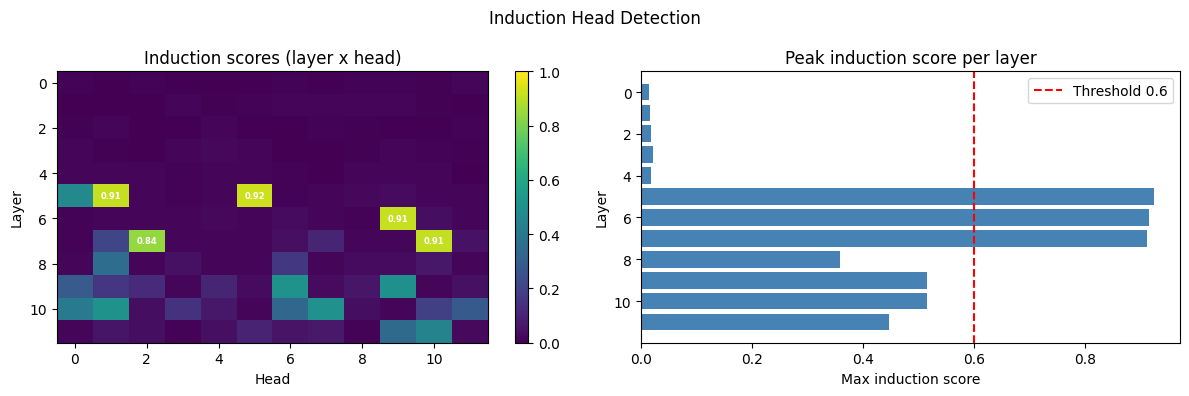

Strong induction heads (score > 0.6):
  L5H1: 0.912
  L5H5: 0.924
  L6H9: 0.914
  L7H2: 0.840
  L7H10: 0.910


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Induction Head Detection', fontsize=12)

# Heatmap
im = axes[0].imshow(scores, cmap='viridis', vmin=0, vmax=1, aspect='auto')
axes[0].set_xlabel('Head')
axes[0].set_ylabel('Layer')
axes[0].set_title('Induction scores (layer x head)')
plt.colorbar(im, ax=axes[0])

# Annotate heads above threshold
THRESHOLD = 0.6
for l in range(n_layers):
    for h in range(n_heads):
        if scores[l, h] > THRESHOLD:
            axes[0].text(h, l, f'{scores[l,h]:.2f}', ha='center', va='center',
                         fontsize=6, color='white', fontweight='bold')

# Bar chart: max score per layer
max_per_layer = scores.max(axis=1)
axes[1].barh(range(n_layers), max_per_layer, color='steelblue')
axes[1].invert_yaxis()
axes[1].axvline(THRESHOLD, color='red', linestyle='--', label=f'Threshold {THRESHOLD}')
axes[1].set_xlabel('Max induction score')
axes[1].set_ylabel('Layer')
axes[1].set_title('Peak induction score per layer')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/induction_scores.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Strong induction heads (score > {THRESHOLD}):')
for l in range(n_layers):
    for h in range(n_heads):
        if scores[l, h] > THRESHOLD:
            print(f'  L{l}H{h}: {scores[l,h]:.3f}')